In [1]:
import __init__ # puts us in the right env

Navigated to package root


### Full workflow for structure recovery from a raw experimental XRD scan

The continuous-XRD models condition CIF generation on the whole powder pattern, which is an upgrade from our previous picked peak list limited to 20 peaks between a 2theta of 0 and 90. The conditioning signal is a `(1000, 2)` `[Q, I]` profile on the fixed grid `Q = 0-10` A^-1. We make it by:
- taking in raw scan data
- then we do 2theta-to-Q conversion
- then SNIP background removal
- grid resample
- max-normalization.

A Perceiver Resampler compresses the profile into prefix key-value tokens for every transformer layer.

This notebook generates with the released model. We use an experimental scan of rutile TiO2 as a demo here.

> **To train your model, you need to go to [CrystaLLM-graph](https://github.com/C-Bone-UCL/CrystaLLM-graph)**, this repo serves as a Zoo to generate from crystallm-pi families, but the specialised knowledge distillation pipelines come from the other paper's repo

#### Inspect the raw-scan conversion

`process_exp_xrd_continuous.py` is the converter the generation pipeline calls internally for `--xrd_files`. Its `--save_plot` renders the four transform stages so the conversion can be sanity-checked before spending GPU time.

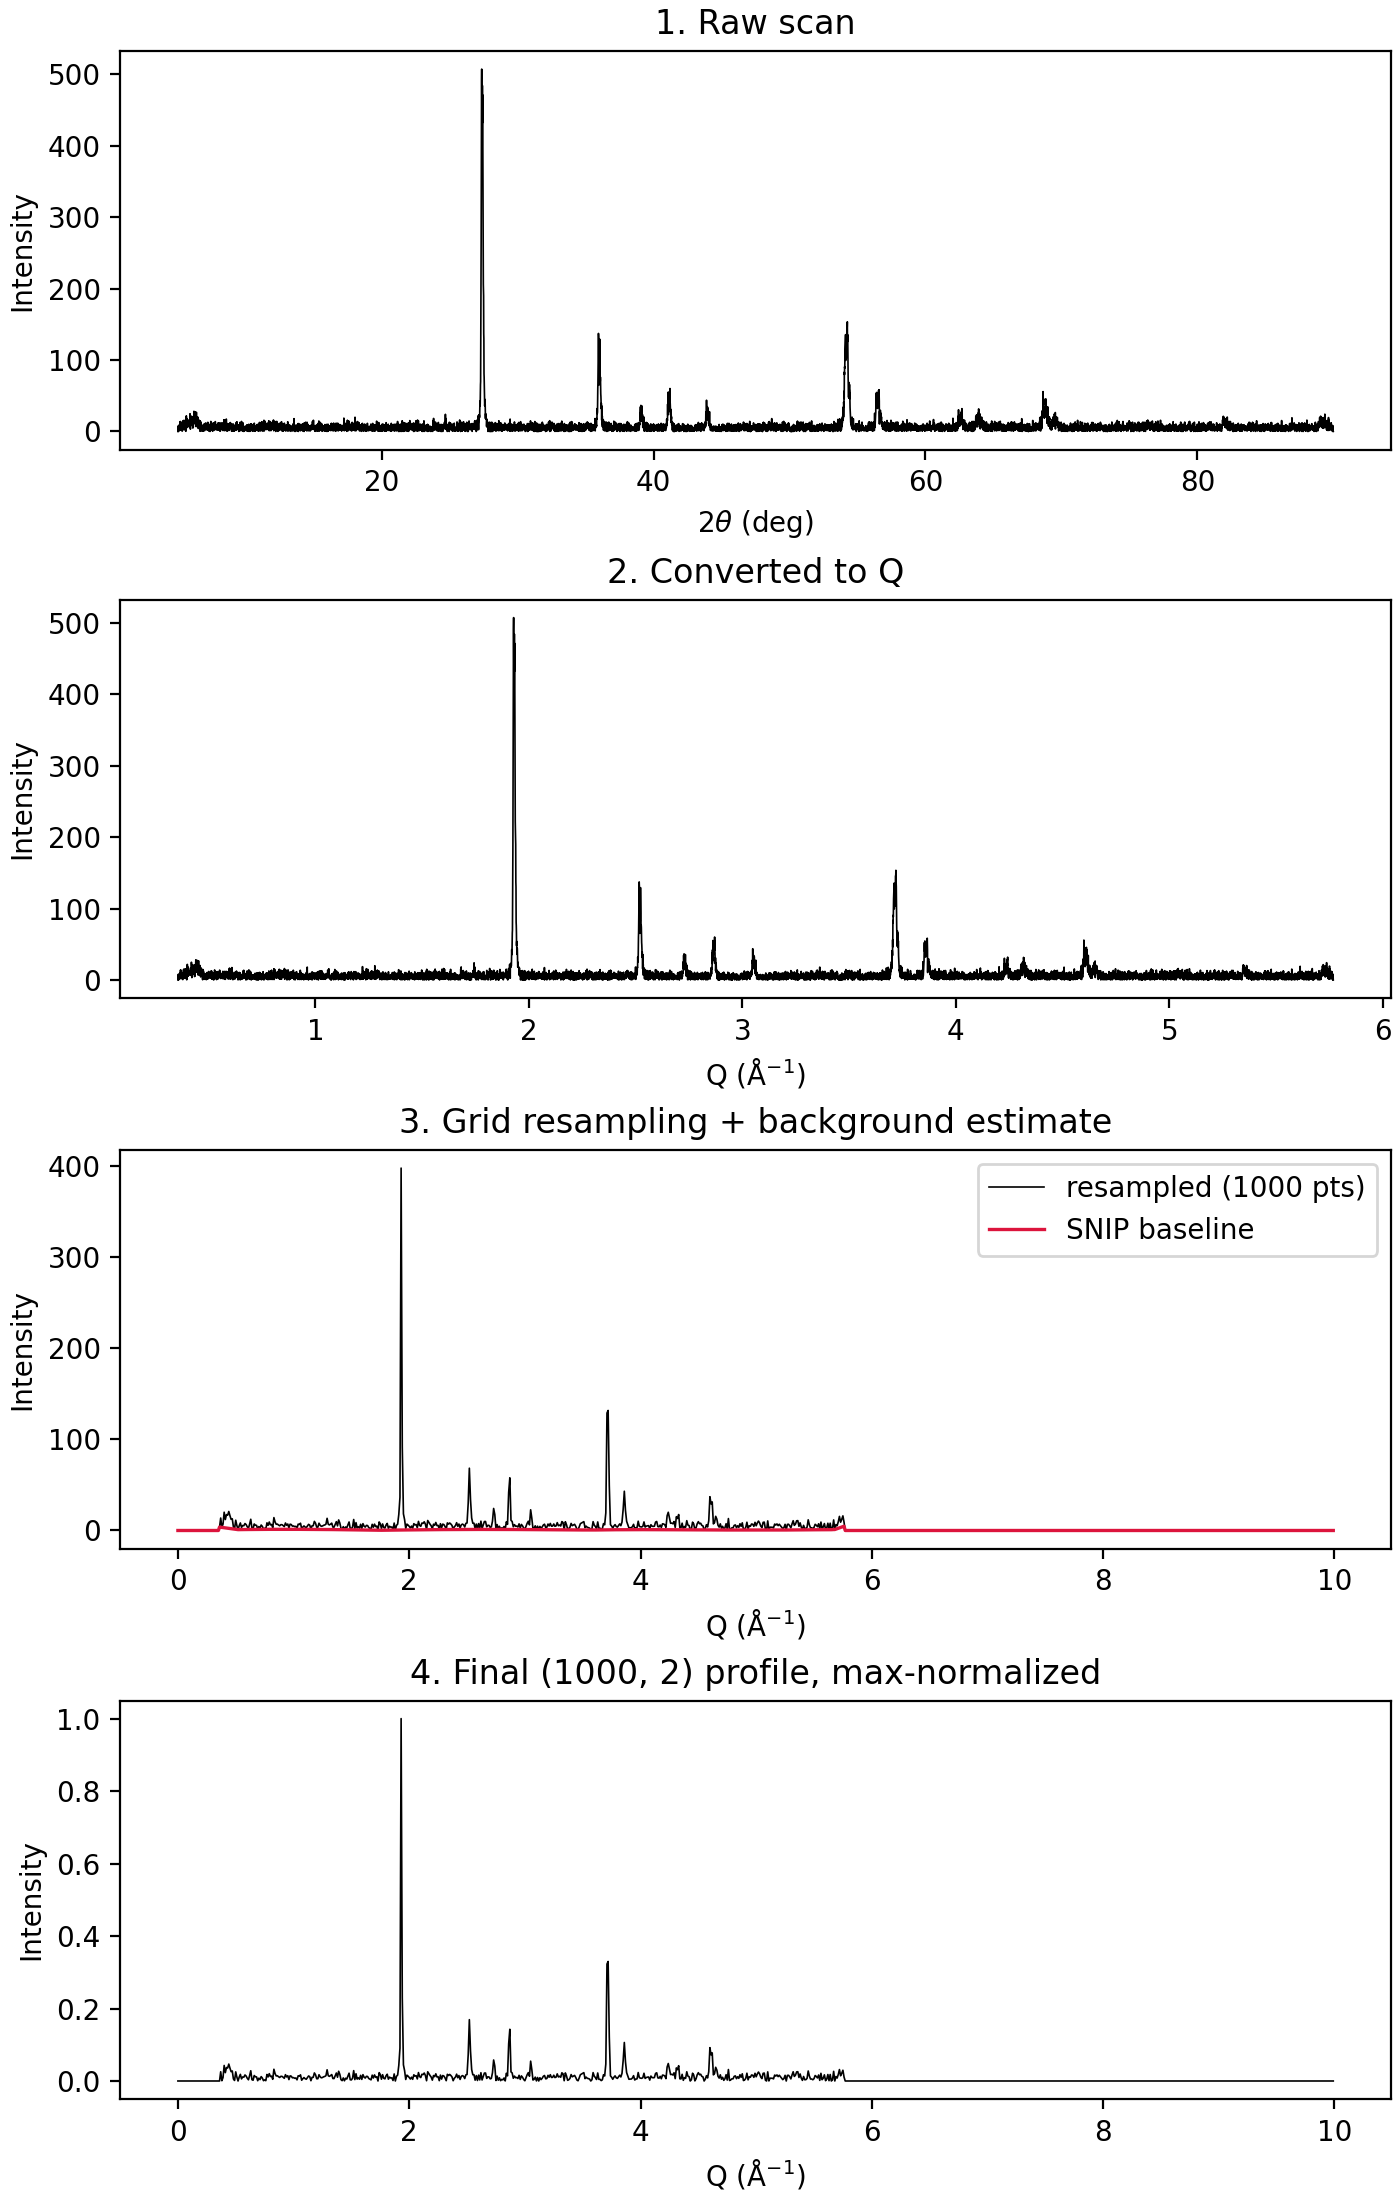

In [2]:
from _utils._preprocessing.process_exp_xrd_continuous import save_pipeline_plot
from IPython.display import Image

save_pipeline_plot(
    "tests/fixtures/Rutile-TiO2-unproc.txt",
    "outputs/cxrd_demo/rutile_pipeline.png",
    wavelength=1.54059,
)
Image("outputs/cxrd_demo/rutile_pipeline.png", width=600)

Panel 1 is the raw scan, panel 2 the same peaks in Q, panel 3 the resampled profile with the SNIP background estimate, and panel 4 the max-normalised profile the model actually sees. Everything outside the measured range is zero.

Q-space is wavelength-independent, so the wavelength is only needed to map 2theta onto the grid. Pass `--xrd_wavelength` for anything that is not CuKalpha1, otherwise 1.54056 A is assumed with a warning. Header text in scan files is never interpreted, only the numbers are.

#### Generate a structure from the scan

We do not know how many formula units are in the cell ahead of time, so `--search_zs` sweeps Z and `--scoring_mode PEARSON` ranks the sweep by XRD fit: every valid candidate's diffraction pattern is simulated and compared to the input profile, and the best match wins. PEARSON is the automatic default for continuous-XRD models when no scoring mode is given, so API callers can simply omit it. Prompts are `level_3`, which gives the model the composition and atomic information.

In [3]:
!python _load_and_generate.py \
    --hf_model_path c-bone/CrystaLLM-pi_alex_mp_20-cXRD \
    --reduced_formula_list TiO2 \
    --search_zs \
    --scoring_mode PEARSON \
    --xrd_files tests/fixtures/Rutile-TiO2-unproc.txt \
    --xrd_wavelength 1.54059 \
    --level level_3 \
    --num_return_sequences 10 \
    --max_return_attempts 1 \
    --target_valid_cifs 1 \
    --output_cif_dir outputs/cxrd_demo


Model Configuration
Path: c-bone/CrystaLLM-pi_alex_mp_20-cXRD
Type: PrefixXRD
Task: Continuous-XRD conditioned generation (PrefixXRD, alex_mp_20 KD student)

Executing Batch Generation


Tokenizer validation passed: token vocabulary is consistent.


Tokenizer validation passed: token vocabulary is consistent.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


Generating CIFs...:   0%|                                 | 0/5 [00:00<?, ?it/s]

Tokenizer validation passed: token vocabulary is consistent.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


...

XRD fit:  91%|██████████████████████████████▉   | 41/45 [00:01<00:00, 18.54it/s]

XRD fit:  96%|████████████████████████████████▍ | 43/45 [00:01<00:00, 16.76it/s]

XRD fit: 100%|██████████████████████████████████| 45/45 [00:02<00:00, 21.62it/s]

Converting CIFs to standard CIF format
Processing 1 records using 4 worker(s)


Processing Generated CIF: 100%|███████████████████| 1/1 [00:00<00:00, 61.63it/s]


Multi-worker processing completed: 1 records

Process Complete
Saved 1 CIF files to: outputs/cxrd_demo


#### The recovered polymorph

In [4]:
from pathlib import Path

from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

# Newest CIF, so reruns are not shadowed by files from earlier demos.
cif_path = max(Path("outputs/cxrd_demo").glob("*.cif"), key=lambda p: p.stat().st_mtime)
structure = Structure.from_file(cif_path)

print(cif_path.read_text())
print(f"Detected space group: {SpacegroupAnalyzer(structure, symprec=0.1).get_space_group_symbol()}")


data_Ti2O4
_symmetry_space_group_name_H-M P4_2/mnm
_cell_length_a 4.5987
_cell_length_b 4.5987
_cell_length_c 2.9418
_cell_angle_alpha 90.0000
_cell_angle_beta 90.0000
_cell_angle_gamma 90.0000
_symmetry_Int_Tables_number 136
_chemical_formula_structural TiO2
_chemical_formula_sum 'Ti2 O4'
_cell_volume 62.5833
_cell_formula_units_Z 2
loop_
 _symmetry_equiv_pos_site_id
 _symmetry_equiv_pos_as_xyz
  1 'x, y, -z'
  2 '-y-1/2, x-1/2, -z-1/2'
  3 '-x-1/2, y-1/2, z-1/2'
  4 'y+1/2, -x+1/2, z+1/2'
  5 'x+1/2, -y+1/2, -z+1/2'
  6 '-y+1/2, x+1/2, z+1/2'
  7 '-x, -y, z'
  8 'x, y, z'
  9 'y, x, -z'
  10 '-x+1/2, y+1/2, -z+1/2'
  11 '-y, -x, -z'
  12 '-x, -y, -z'
  13 'y-1/2, -x-1/2, -z-1/2'
  14 '-y, -x, z'
  15 'x-1/2, -y-1/2, z-1/2'
  16 'y, x, z'
loop_
 _atom_site_type_symbol
 _atom_site_label
 _atom_site_symmetry_multiplicity
 _atom_site_fract_x
 _atom_site_fract_y
 _atom_site_fract_z
 _atom_site_occupancy
 Ti Ti0 2 0.0000 0.0000 0.0000 1.0
 O O1 4 0.1987 0.8013 0.5000 1.0

Detected space g